# MWE: uv lattices and the matrix Fourier transform

AMI data processed by AMIGO are sampled on the detector's Fourier grid: the uv samples lie exactly on a regular lattice, rotated on the sky by the parallactic angle. On such a lattice the Fourier sum over an image's pixels separates into two small matrix products, the two-sided matrix Fourier transform (MFT) of Soummer et al. (2007). It is exact and much cheaper than summing over each uv point separately, but only if the image's pixel lattice is rotated to match the uv lattice.

virgil finds the lattice when the data are loaded (`OIData.uv_grid`), and an `Image` whose `rotation_deg` matches it uses the MFT automatically; every other model is evaluated point by point as before. This notebook shows the lattice, the rotated pixels, that the MFT gives the same answer, and how much faster it is. You should come away knowing how to set up an image for AMI data.

In [1]:
import sys
import time
from pathlib import Path

root = next(
    p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").exists()
)
sys.path.insert(0, str(root / "src"))

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as onp
from tqdm.auto import tqdm

from virgil._geometry import rotate
from virgil.coverage import ami_grid_record
from virgil.likelihood import model_loglike
from virgil.models import Image, ModulatedGaussianRim, PointSource, System
from virgil.oidata import OIData
from virgil.plotting import plot_model

data = OIData(ami_grid_record(rotation_deg=-6.9))
grid = data.uv_grid
print(
    f"{data.u.size} uv samples on a {grid.u_axis.size} x {grid.v_axis.size} lattice, rotated by {grid.rotation_deg:.2f} deg"
)
print(
    f"{data.vis.size} DISCO-like modes, with errors from {float(data.d_vis.min()):.0e} to {float(data.d_vis.max()):.0e}"
)

412 uv samples on a 35 x 19 lattice, rotated by -6.90 deg
588 DISCO-like modes, with errors from 2e-04 to 4e-03


## The lattice on the sky and in its own frame

On the sky the samples are the splodges of a tilted half-plane of the grid. Rotating them back by the lattice angle (`rotate(u, v, -rotation)`) lines them up with the axes, which is the frame in which the transform separates. Negating u and v gives the other half of the plane, since the image is real.

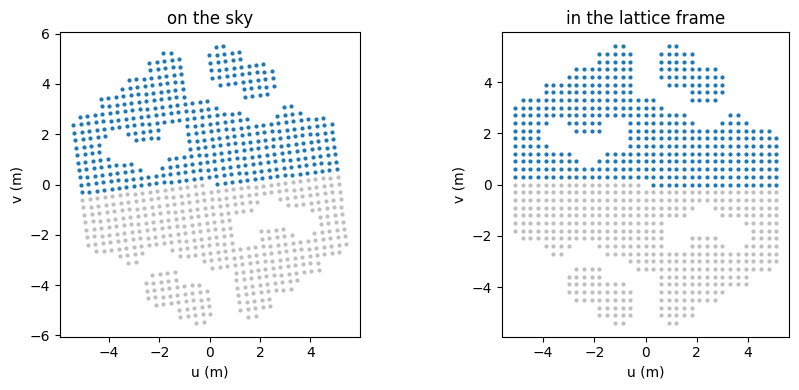

In [2]:
gu, gv = rotate(data.u, data.v, -grid.rotation_deg)
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, (a, b), title in zip(
    axes, [(data.u, data.v), (gu, gv)], ["on the sky", "in the lattice frame"]
):
    ax.plot(a, b, ".", ms=4)
    ax.plot(-a, -b, ".", ms=4, color="0.75")
    ax.set(xlabel="u (m)", ylabel="v (m)", title=title, aspect="equal")
plt.tight_layout()
plt.show()

## Pixels that follow the detector

`Image(..., rotation_deg=θ)` lays its pixels on a lattice whose "up" axis points at position angle θ, measured from North towards East. `from_model` samples a model onto those rotated pixels, and `render` (and so `plot_model`) resamples back to North up for display. The rotation is exaggerated to 30° here, and the dashed outline shows where the rotated pixel grid lies on the sky; the source itself stays where it is.

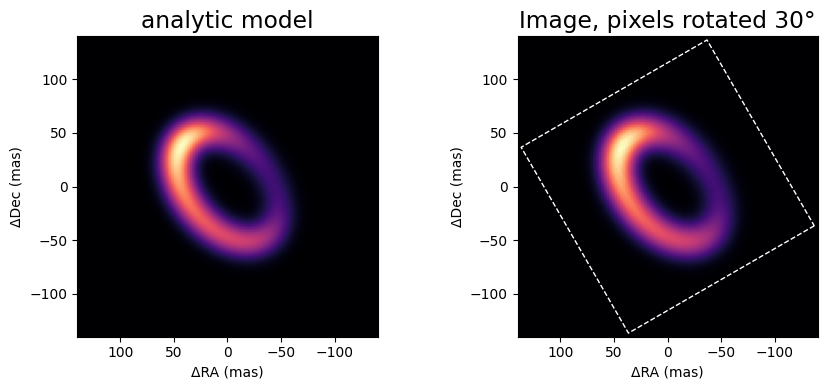

In [3]:
rim = ModulatedGaussianRim(
    diam=120.0,
    fwhm=25.0,
    inc=50.0,
    pa=40.0,
    az_amps=jnp.array([0.6]),
    az_pas=jnp.array([90.0]),
)
tilted = Image.from_model(rim, 40, 5.0, rotation_deg=30.0)
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
plot_model(rim, fov_mas=280.0, npix=112, ax=axes[0], title="analytic model")
plot_model(
    tilted,
    fov_mas=280.0,
    npix=112,
    ax=axes[1],
    title="Image, pixels rotated 30°",
)
corners = 100.0 * jnp.array([[-1, -1], [1, -1], [1, 1], [-1, 1], [-1, -1]])
edge_x, edge_y = rotate(corners[:, 0], corners[:, 1], 30.0)
axes[1].plot(edge_x, edge_y, "w--", lw=1)
plt.tight_layout()
plt.show()

## The MFT gives the same answer

With the image rotated to match the data (here −6.9°, a realistic parallactic angle), `OIData.model` takes the lattice path. Removing the lattice from the data forces the exact point-by-point sum, and the two agree to float32 rounding. An image whose rotation does not match simply falls back to the point-by-point sum, so a mismatch costs speed, never accuracy.

In [4]:
image = Image.from_model(
    rim, 48, 5.0, rotation_deg=grid.rotation_deg, flux=0.2
)
scene = System(star=PointSource(), env=image)
per_point = eqx.tree_at(
    lambda d: d.uv_grid, data, None, is_leaf=lambda x: x is None
)
difference = jnp.abs(data.model(scene) - per_point.model(scene)).max()
print(
    f"largest difference between the MFT and point-by-point paths: {difference:.1e}"
)
print(f"largest DISCO observable: {jnp.abs(per_point.model(scene)).max():.1e}")

largest difference between the MFT and point-by-point paths: 1.6e-07
largest DISCO observable: 1.1e-01


## How much faster

This cell times a jitted value-and-gradient of the log-likelihood with respect to the pixels, on a lattice as fine as the real ν Hor product (0.2165 m pitch, about 800 cells in the splodges), for a range of image sizes. The point-by-point cost grows as npix² and the MFT's more slowly, so the advantage grows with the image. The fixed projection onto the DISCO modes is included in both.

MFT:   0%|          | 0/4 [00:00<?, ?it/s]

per point:   0%|          | 0/4 [00:00<?, ?it/s]

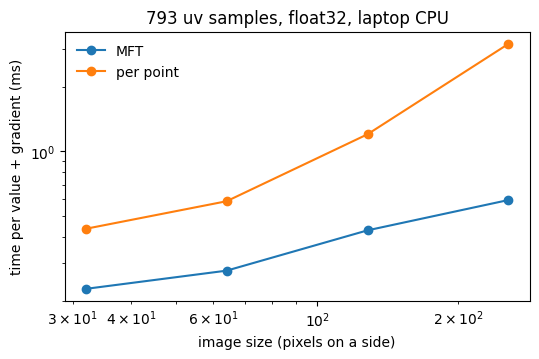

In [5]:
fine = OIData(ami_grid_record(pitch_m=0.2165, rotation_deg=-6.9))
fine_per_point = eqx.tree_at(
    lambda d: d.uv_grid, fine, None, is_leaf=lambda x: x is None
)


def timed(d, npix):
    base = System(
        star=PointSource(),
        env=Image(
            jnp.zeros((npix, npix)),
            400.0 / npix,
            flux=0.2,
            rotation_deg=fine.uv_grid.rotation_deg,
        ),
    )
    step = jax.jit(
        jax.value_and_grad(
            lambda lb: model_loglike(base.set("env.log_brightness", lb), d)
        )
    )
    lb = jnp.asarray(onp.random.default_rng(0).normal(size=(npix, npix)))
    jax.block_until_ready(step(lb))
    start = time.perf_counter()
    for _ in range(10):
        jax.block_until_ready(step(lb))
    return (time.perf_counter() - start) * 100.0


sizes = [32, 64, 128, 256]
times = {
    name: [timed(d, n) for n in tqdm(sizes, desc=name)]
    for name, d in [("MFT", fine), ("per point", fine_per_point)]
}
fig, ax = plt.subplots(figsize=(6, 3.5))
for name, ms in times.items():
    ax.loglog(sizes, ms, "-o", label=name)
ax.set(
    xlabel="image size (pixels on a side)",
    ylabel="time per value + gradient (ms)",
    title=f"{fine.u.size} uv samples, float32, laptop CPU",
)
ax.legend(frameon=False)
plt.show()

## Summary

When data lie on a uv lattice, as AMIGO DISCO products do, virgil records the lattice at load time, and an `Image` rotated to match it (`rotation_deg=data.uv_grid.rotation_deg`) is transformed with the exact two-sided MFT. The answer is the same as the point-by-point sum, only faster, and any other model or rotation falls back to that sum automatically. For AMI imaging, lay the pixels along the detector and let `render` show them North up.